In [3]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 连接OKX
exchange = ccxt.okx()

# 测试：拉取BTC/USDT日线数据
ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", limit=10)
df = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df.set_index("date")

print(df)

                timestamp     open     high      low    close        volume
date                                                                       
2026-03-19  1773878400000  71253.1  71618.0  68796.3  69923.7   7331.205854
2026-03-20  1773964800000  69923.7  71366.0  69393.5  70515.7   5670.280110
2026-03-21  1774051200000  70515.6  71100.0  68555.0  68921.1   3290.103972
2026-03-22  1774137600000  68921.1  69584.8  67360.1  67860.1   4774.157931
2026-03-23  1774224000000  67860.1  71809.4  67452.4  70900.0  10569.061730
2026-03-24  1774310400000  70900.0  71400.0  68924.0  70557.5   6869.959830
2026-03-25  1774396800000  70557.5  72012.0  70414.1  71334.9   5943.669683
2026-03-26  1774483200000  71334.9  71440.9  68153.3  68827.2   6581.532381
2026-03-27  1774569600000  68827.2  69185.6  65559.6  66403.9   9636.054943
2026-03-28  1774656000000  66403.9  67169.0  65933.2  66736.1   2443.163999


In [4]:
# 拉取更长的历史数据（500天）
ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", limit=500)
df_btc = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df_btc["date"] = pd.to_datetime(df_btc["timestamp"], unit="ms")
df_btc = df_btc.set_index("date")
df_btc = df_btc.drop(columns=["timestamp"])

# 保存本地
df_btc.to_csv("btc_daily.csv")

print(f"数据维度：{df_btc.shape}")
print(f"时间范围：{df_btc.index[0].date()} 到 {df_btc.index[-1].date()}")
print(df_btc.tail())

数据维度：(300, 5)
时间范围：2025-06-02 到 2026-03-28
               open     high      low    close       volume
date                                                       
2026-03-24  70900.0  71400.0  68924.0  70557.5  6869.959830
2026-03-25  70557.5  72012.0  70414.1  71334.9  5943.669683
2026-03-26  71334.9  71440.9  68153.3  68827.2  6581.532381
2026-03-27  68827.2  69185.6  65559.6  66403.9  9636.054943
2026-03-28  66403.9  67169.0  65933.2  66738.0  2443.306740


In [5]:
# 分批拉取更长历史数据
all_ohlcv = []
since = exchange.parse8601("2023-01-01T00:00:00Z")

while True:
    ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", since=since, limit=300)
    if len(ohlcv) == 0:
        break
    all_ohlcv += ohlcv
    since = ohlcv[-1][0] + 86400000  # 下一天
    if ohlcv[-1][0] >= exchange.milliseconds():
        break
    time.sleep(0.5)

df_btc = pd.DataFrame(all_ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df_btc["date"] = pd.to_datetime(df_btc["timestamp"], unit="ms")
df_btc = df_btc.set_index("date")
df_btc = df_btc.drop(columns=["timestamp"])
df_btc = df_btc[~df_btc.index.duplicated()]
df_btc.to_csv("btc_daily.csv")

print(f"数据维度：{df_btc.shape}")
print(f"时间范围：{df_btc.index[0].date()} 到 {df_btc.index[-1].date()}")

数据维度：(1183, 5)
时间范围：2023-01-01 到 2026-03-28


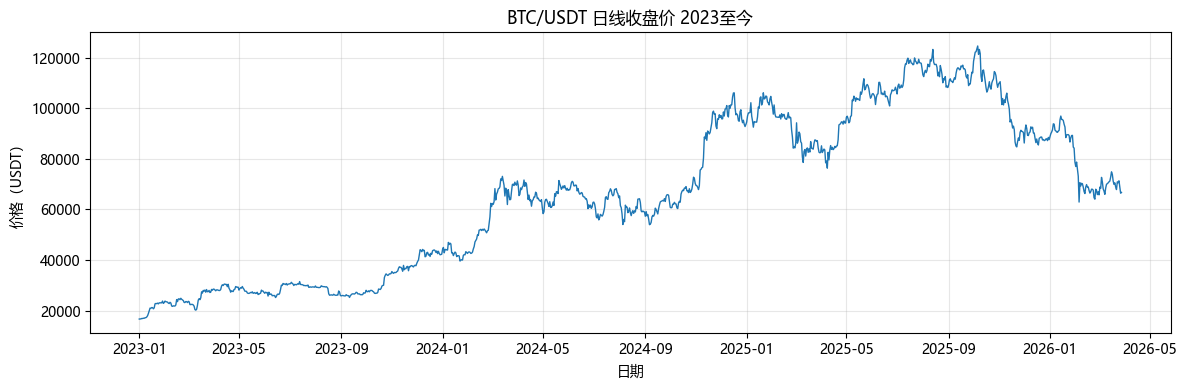

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df_btc.index, df_btc["close"], linewidth=1)
plt.title("BTC/USDT 日线收盘价 2023至今")
plt.xlabel("日期")
plt.ylabel("价格（USDT）")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
symbols = [
    "BTC/USDT", "ETH/USDT", "BNB/USDT", "SOL/USDT", "XRP/USDT",
    "DOGE/USDT", "ADA/USDT", "TRX/USDT", "HYPE/USDT", "LINK/USDT"
]

close_crypto = {}

for symbol in symbols:
    try:
        ohlcv = []
        since = exchange.parse8601("2023-01-01T00:00:00Z")
        while True:
            batch = exchange.fetch_ohlcv(symbol, timeframe="1d", since=since, limit=300)
            if len(batch) == 0:
                break
            ohlcv += batch
            since = batch[-1][0] + 86400000
            if batch[-1][0] >= exchange.milliseconds():
                break
            time.sleep(0.3)
        
        df_temp = pd.DataFrame(ohlcv, columns=["timestamp","open","high","low","close","volume"])
        df_temp["date"] = pd.to_datetime(df_temp["timestamp"], unit="ms")
        df_temp = df_temp.set_index("date")["close"]
        df_temp = df_temp[~df_temp.index.duplicated()]
        close_crypto[symbol.replace("/USDT","")] = df_temp
        print(f"完成：{symbol}")
        time.sleep(0.5)
    except Exception as e:
        print(f"失败：{symbol} {e}")

close_crypto_df = pd.DataFrame(close_crypto)
close_crypto_df.to_csv("crypto_close.csv")
print(f"\n完成，维度：{close_crypto_df.shape}")

完成：BTC/USDT
完成：ETH/USDT
完成：BNB/USDT
完成：SOL/USDT
完成：XRP/USDT
完成：DOGE/USDT
完成：ADA/USDT
完成：TRX/USDT
完成：HYPE/USDT
完成：LINK/USDT

完成，维度：(1183, 10)


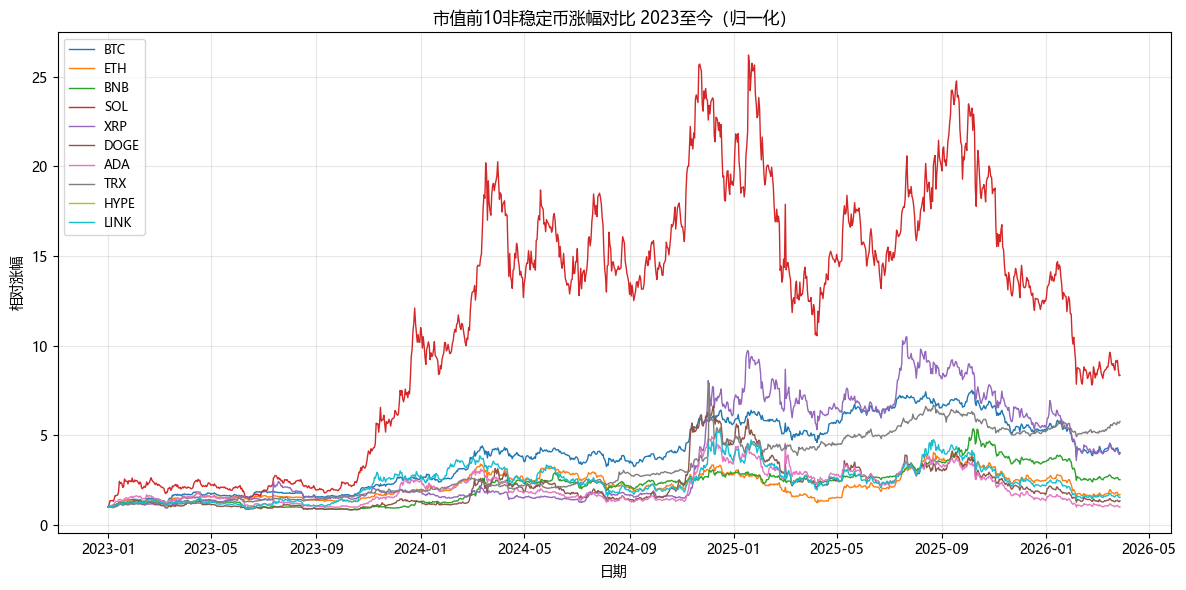

In [11]:
# 归一化到1，方便对比
close_norm = close_crypto_df / close_crypto_df.iloc[0]

plt.figure(figsize=(12, 6))
for col in close_norm.columns:
    plt.plot(close_norm.index, close_norm[col], linewidth=1, label=col)

plt.title("市值前10非稳定币涨幅对比 2023至今（归一化）")
plt.xlabel("日期")
plt.ylabel("相对涨幅")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# 读取数据
close_crypto_df = pd.read_csv("crypto_close.csv", index_col=0, parse_dates=True)

# 计算20日动量因子
momentum = close_crypto_df / close_crypto_df.shift(20) - 1

# 未来10天涨幅（预测目标）
future_return = close_crypto_df.shift(-10) / close_crypto_df - 1

# 每天计算截面IC
ic_list = []
dates_list = []

for date in momentum.index:
    factor_row = momentum.loc[date].dropna()
    if date not in future_return.index:
        continue
    return_row = future_return.loc[date].dropna()
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 5:
        continue
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_list.append(ic)
    dates_list.append(date)

ic_momentum = pd.Series(ic_list, index=dates_list)

print(f"动量因子 IC均值：{ic_momentum.mean():.4f}")
print(f"动量因子 IC标准差：{ic_momentum.std():.4f}")
print(f"动量因子 ICIR：{ic_momentum.mean()/ic_momentum.std():.4f}")
print(f"动量因子 IC>0的比例：{(ic_momentum>0).mean():.2%}")

动量因子 IC均值：0.0270
动量因子 IC标准差：0.4183
动量因子 ICIR：0.0644
动量因子 IC>0的比例：52.21%


In [13]:
# 反转因子：过去5天跌得多的币，接下来反弹
reversal = -(close_crypto_df / close_crypto_df.shift(5) - 1)

ic_list2 = []
dates_list2 = []

for date in reversal.index:
    factor_row = reversal.loc[date].dropna()
    if date not in future_return.index:
        continue
    return_row = future_return.loc[date].dropna()
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 5:
        continue
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_list2.append(ic)
    dates_list2.append(date)

ic_reversal = pd.Series(ic_list2, index=dates_list2)

print(f"反转因子 IC均值：{ic_reversal.mean():.4f}")
print(f"反转因子 IC标准差：{ic_reversal.std():.4f}")
print(f"反转因子 ICIR：{ic_reversal.mean()/ic_reversal.std():.4f}")
print(f"反转因子 IC>0的比例：{(ic_reversal>0).mean():.2%}")

反转因子 IC均值：0.0023
反转因子 IC标准差：0.3879
反转因子 ICIR：0.0059
反转因子 IC>0的比例：49.83%


In [14]:
# 计算MACD
close = close_crypto_df["BTC"].dropna()

# EMA12 和 EMA26
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()

# MACD线 和 信号线
macd = ema12 - ema26
signal = macd.ewm(span=9, adjust=False).mean()

# 金叉死叉信号
cross = pd.Series(0, index=close.index)
cross[macd > signal] = 1   # 金叉：持仓
cross[macd < signal] = 0   # 死叉：空仓

print(f"持仓天数比例：{cross.mean():.2%}")
print(cross.value_counts())

持仓天数比例：48.77%
0    606
1    577
Name: count, dtype: int64


MACD策略 累计收益：135.44%
MACD策略 年化收益：30.27%
MACD策略 最大回撤：-32.10%
MACD策略 Sharpe：0.9987
BTC买入持有 累计收益：301.92%


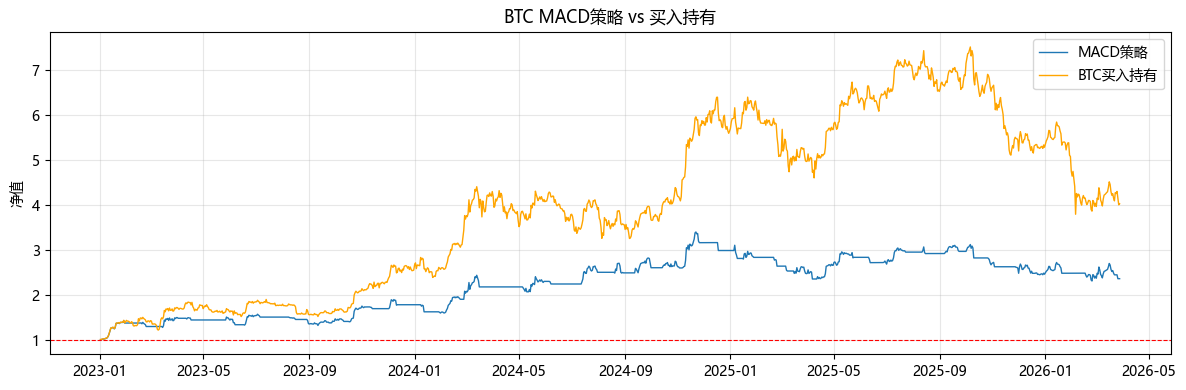

In [16]:
# MACD择时回测
returns = close.pct_change().dropna()
signal_shifted = cross.shift(1).dropna()  # 用昨天的信号决定今天是否持仓

# 对齐
common = returns.index.intersection(signal_shifted.index)
strategy_returns = returns[common] * signal_shifted[common]

# 计算净值
portfolio = (1 + strategy_returns).cumprod()
buy_hold = (1 + returns[common]).cumprod()

# 指标
total_return = portfolio.iloc[-1] - 1
annual_return = (1 + total_return) ** (365/len(portfolio)) - 1
max_drawdown = ((portfolio - portfolio.cummax()) / portfolio.cummax()).min()
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(365)
bh_return = buy_hold.iloc[-1] - 1

print(f"MACD策略 累计收益：{total_return:.2%}")
print(f"MACD策略 年化收益：{annual_return:.2%}")
print(f"MACD策略 最大回撤：{max_drawdown:.2%}")
print(f"MACD策略 Sharpe：{sharpe:.4f}")
print(f"BTC买入持有 累计收益：{bh_return:.2%}")

# 画图
plt.figure(figsize=(12, 4))
plt.plot(portfolio.index, portfolio, linewidth=1, label="MACD策略")
plt.plot(buy_hold.index, buy_hold, linewidth=1, label="BTC买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC MACD策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# 测试不同参数组合
results = []

for fast in [8, 12, 16, 20]:
    for slow in [21, 26, 30, 35]:
        for signal_period in [7, 9, 12]:
            if fast >= slow:
                continue
            
            ema_fast = close.ewm(span=fast, adjust=False).mean()
            ema_slow = close.ewm(span=slow, adjust=False).mean()
            macd_line = ema_fast - ema_slow
            signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
            
            cross = pd.Series(0, index=close.index)
            cross[macd_line > signal_line] = 1
            cross[macd_line < signal_line] = 0
            
            ret = close.pct_change().dropna()
            sig = cross.shift(1).dropna()
            common = ret.index.intersection(sig.index)
            strat_ret = ret[common] * sig[common]
            
            pv = (1 + strat_ret).cumprod()
            total_ret = pv.iloc[-1] - 1
            sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
            dd = ((pv - pv.cummax()) / pv.cummax()).min()
            
            results.append({
                "fast": fast, "slow": slow, "signal": signal_period,
                "累计收益": total_ret, "Sharpe": sharpe, "最大回撤": dd
            })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("Sharpe", ascending=False)
print(df_results.head(10).to_string(index=False))

 fast  slow  signal     累计收益   Sharpe      最大回撤
   16    35       9 3.389462 1.607901 -0.216499
   20    26      12 3.205109 1.578501 -0.248990
   16    30      12 3.172889 1.573581 -0.221713
   20    30       9 3.144332 1.560335 -0.219086
   20    35       9 2.934959 1.521389 -0.235412
   20    26       9 2.936256 1.499362 -0.244605
   20    30       7 2.823132 1.472624 -0.223286
   20    35       7 2.728440 1.458487 -0.231127
   16    26      12 2.684006 1.437991 -0.244605
   20    21      12 2.644962 1.437645 -0.242010


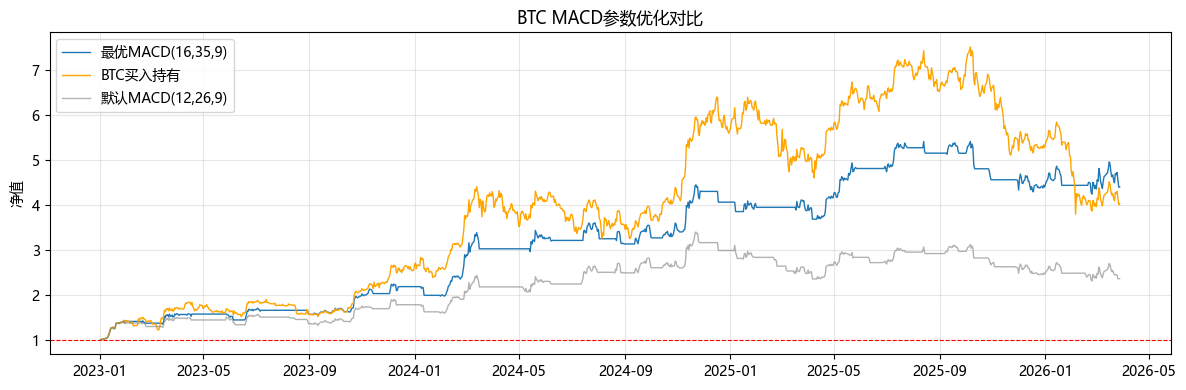

In [18]:
# 用最优参数重新回测
ema_fast = close.ewm(span=16, adjust=False).mean()
ema_slow = close.ewm(span=35, adjust=False).mean()
macd_best = ema_fast - ema_slow
signal_best = macd_best.ewm(span=9, adjust=False).mean()

cross_best = pd.Series(0, index=close.index)
cross_best[macd_best > signal_best] = 1
cross_best[macd_best < signal_best] = 0

ret = close.pct_change().dropna()
sig = cross_best.shift(1).dropna()
common = ret.index.intersection(sig.index)
strat_ret = ret[common] * sig[common]

portfolio_best = (1 + strat_ret).cumprod()
buy_hold = (1 + ret[common]).cumprod()

plt.figure(figsize=(12, 4))
plt.plot(portfolio_best.index, portfolio_best, linewidth=1, label="最优MACD(16,35,9)")
plt.plot(buy_hold.index, buy_hold, linewidth=1, label="BTC买入持有", color="orange")
plt.plot(portfolio.index, portfolio, linewidth=1, label="默认MACD(12,26,9)", color="gray", alpha=0.6)
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC MACD参数优化对比")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Walk-Forward验证
# 把数据切成3段，每段用前2/3找参数，后1/3验证

total_days = len(close)
segment = total_days // 3

results_wf = []

for i in range(3):
    # 训练集和验证集
    train_start = i * segment
    train_end = train_start + int(segment * 0.67)
    test_start = train_end
    test_end = min(train_start + segment, total_days)
    
    train = close.iloc[train_start:train_end]
    test = close.iloc[test_start:test_end]
    
    # 在训练集上找最优参数
    best_sharpe = -999
    best_params = None
    
    for fast in [8, 12, 16, 20]:
        for slow in [21, 26, 30, 35]:
            for signal_period in [7, 9, 12]:
                if fast >= slow:
                    continue
                ema_f = train.ewm(span=fast, adjust=False).mean()
                ema_s = train.ewm(span=slow, adjust=False).mean()
                m = ema_f - ema_s
                sig = m.ewm(span=signal_period, adjust=False).mean()
                cross = pd.Series(0, index=train.index)
                cross[m > sig] = 1
                ret = train.pct_change().dropna()
                sr = cross.shift(1).dropna()
                common = ret.index.intersection(sr.index)
                strat = ret[common] * sr[common]
                if strat.std() == 0:
                    continue
                sharpe = strat.mean() / strat.std() * np.sqrt(365)
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_params = (fast, slow, signal_period)
    
    # 用最优参数在验证集上测试
    f, s, sp = best_params
    ema_f = test.ewm(span=f, adjust=False).mean()
    ema_s = test.ewm(span=s, adjust=False).mean()
    m = ema_f - ema_s
    sig = m.ewm(span=sp, adjust=False).mean()
    cross = pd.Series(0, index=test.index)
    cross[m > sig] = 1
    ret = test.pct_change().dropna()
    sr = cross.shift(1).dropna()
    common = ret.index.intersection(sr.index)
    strat = ret[common] * sr[common]
    sharpe_test = strat.mean() / strat.std() * np.sqrt(365)
    
    results_wf.append({
        "段": f"第{i+1}段",
        "训练集最优参数": best_params,
        "训练集Sharpe": round(best_sharpe, 4),
        "验证集Sharpe": round(sharpe_test, 4)
    })
    print(f"第{i+1}段完成：最优参数{best_params}，训练Sharpe {best_sharpe:.4f}，验证Sharpe {sharpe_test:.4f}")

df_wf = pd.DataFrame(results_wf)
print(f"\n{df_wf.to_string(index=False)}")
print(f"\n验证集平均Sharpe：{df_wf['验证集Sharpe'].mean():.4f}")

第1段完成：最优参数(20, 26, 12)，训练Sharpe 2.5846，验证Sharpe 1.0949
第2段完成：最优参数(16, 35, 7)，训练Sharpe 2.3437，验证Sharpe 0.4917
第3段完成：最优参数(12, 26, 12)，训练Sharpe 0.6344，验证Sharpe -0.2821

  段      训练集最优参数  训练集Sharpe  验证集Sharpe
第1段 (20, 26, 12)     2.5846     1.0949
第2段  (16, 35, 7)     2.3437     0.4917
第3段 (12, 26, 12)     0.6344    -0.2821

验证集平均Sharpe：0.4348


In [23]:
# 重新拉取，换一下参数格式
data = exchange.fetch_funding_rate_history(
    "BTC/USDT:USDT",
    limit=100
)
print(f"数据条数：{len(data)}")
if len(data) > 0:
    print(data[0])

数据条数：100
{'info': {'formulaType': 'withRate', 'fundingRate': '-0.0000915586192191', 'fundingTime': '1771833600000', 'instId': 'BTC-USDT-SWAP', 'instType': 'SWAP', 'method': 'current_period', 'realizedRate': '-0.0000915586192191'}, 'symbol': 'BTC/USDT:USDT', 'fundingRate': -9.15586192191e-05, 'timestamp': 1771833600000, 'datetime': '2026-02-23T08:00:00.000Z'}


In [24]:
# 分批拉取更多资金费率数据
funding_rates = []
end_time = None

for _ in range(10):
    params = {}
    if end_time:
        params["before"] = end_time
    
    data = exchange.fetch_funding_rate_history(
        "BTC/USDT:USDT",
        limit=100,
        params=params
    )
    if not data:
        break
    funding_rates = data + funding_rates
    end_time = data[0]["timestamp"]
    time.sleep(0.3)

df_funding = pd.DataFrame([{
    "date": pd.to_datetime(r["timestamp"], unit="ms"),
    "rate": r["fundingRate"]
} for r in funding_rates])
df_funding = df_funding.set_index("date").sort_index()
df_funding = df_funding[~df_funding.index.duplicated()]
df_funding.to_csv("btc_funding.csv")

print(f"资金费率数据：{df_funding.shape}")
print(f"时间范围：{df_funding.index[0]} 到 {df_funding.index[-1]}")
print(df_funding.tail())

资金费率数据：(100, 1)
时间范围：2026-02-23 08:00:00 到 2026-03-28 08:00:00
                         rate
date                         
2026-03-27 00:00:00  0.000076
2026-03-27 08:00:00  0.000066
2026-03-27 16:00:00 -0.000044
2026-03-28 00:00:00 -0.000030
2026-03-28 08:00:00  0.000011


In [25]:
# 重新拉取，用after参数往前追溯
funding_rates = []
since = exchange.parse8601("2023-01-01T00:00:00Z")

while True:
    data = exchange.fetch_funding_rate_history(
        "BTC/USDT:USDT",
        since=since,
        limit=100
    )
    if not data:
        break
    funding_rates += data
    since = data[-1]["timestamp"] + 1
    if data[-1]["timestamp"] >= exchange.milliseconds():
        break
    time.sleep(0.3)
    print(f"已拉取：{len(funding_rates)}条，最新时间：{pd.to_datetime(data[-1]['timestamp'], unit='ms').date()}")

df_funding = pd.DataFrame([{
    "date": pd.to_datetime(r["timestamp"], unit="ms"),
    "rate": r["fundingRate"]
} for r in funding_rates])
df_funding = df_funding.set_index("date").sort_index()
df_funding = df_funding[~df_funding.index.duplicated()]
df_funding.to_csv("btc_funding.csv")

print(f"\n完成，数据维度：{df_funding.shape}")
print(f"时间范围：{df_funding.index[0]} 到 {df_funding.index[-1]}")

已拉取：100条，最新时间：2026-01-26
已拉取：200条，最新时间：2026-02-28
已拉取：283条，最新时间：2026-03-28

完成，数据维度：(283, 1)
时间范围：2025-12-24 08:00:00 到 2026-03-28 08:00:00


In [26]:
# 用OKX的历史资金费率接口
data = exchange.fetch_funding_rate_history(
    "BTC/USDT:USDT",
    limit=100,
    params={"instId": "BTC-USDT-SWAP"}
)
print(f"条数：{len(data)}")
print(f"最早时间：{pd.to_datetime(data[0]['timestamp'], unit='ms')}")
print(f"最晚时间：{pd.to_datetime(data[-1]['timestamp'], unit='ms')}")

条数：100
最早时间：2026-02-23 08:00:00
最晚时间：2026-03-28 08:00:00


In [34]:
exchange_binance = ccxt.binance({
    'proxies': {
        'http': 'http://127.0.0.1:7897',
        'https': 'http://127.0.0.1:7897',
    },
    'options': {
        'defaultType': 'future'
    }
})

# 测试连接
ping = exchange_binance.fetch_funding_rate_history(
    "BTC/USDT",
    limit=5,
    since=exchange_binance.parse8601("2023-01-01T00:00:00Z")
)
print(f"条数：{len(ping)}")
print(f"最早时间：{pd.to_datetime(ping[0]['timestamp'], unit='ms')}")
print(ping[0])

条数：5
最早时间：2023-01-01 00:00:00
{'info': {'symbol': 'BTCUSDT', 'fundingTime': '1672531200000', 'fundingRate': '0.00010000', 'markPrice': ''}, 'symbol': 'BTC/USDT:USDT', 'fundingRate': 0.0001, 'timestamp': 1672531200000, 'datetime': '2023-01-01T00:00:00.000Z'}


In [35]:
# 从2019年开始拉，尽可能拉最长历史
funding_rates = []
since = exchange_binance.parse8601("2019-01-01T00:00:00Z")

while True:
    data = exchange_binance.fetch_funding_rate_history(
        "BTC/USDT",
        since=since,
        limit=1000
    )
    if not data:
        break
    funding_rates += data
    since = data[-1]["timestamp"] + 1
    if data[-1]["timestamp"] >= exchange_binance.milliseconds():
        break
    time.sleep(0.3)
    print(f"已拉取：{len(funding_rates)}条，最新：{pd.to_datetime(data[-1]['timestamp'], unit='ms').date()}")

df_funding = pd.DataFrame([{
    "date": pd.to_datetime(r["timestamp"], unit="ms"),
    "rate": r["fundingRate"]
} for r in funding_rates])
df_funding = df_funding.set_index("date").sort_index()
df_funding = df_funding[~df_funding.index.duplicated()]
df_funding.to_csv("btc_funding_full.csv")

print(f"\n完成，数据维度：{df_funding.shape}")
print(f"时间范围：{df_funding.index[0]} 到 {df_funding.index[-1]}")

已拉取：1000条，最新：2020-08-08
已拉取：2000条，最新：2021-07-07
已拉取：3000条，最新：2022-06-06
已拉取：4000条，最新：2023-05-05
已拉取：5000条，最新：2024-04-02
已拉取：6000条，最新：2025-03-02
已拉取：7000条，最新：2026-01-29
已拉取：7174条，最新：2026-03-28

完成，数据维度：(7174, 1)
时间范围：2019-09-10 08:00:00 到 2026-03-28 08:00:00.005000


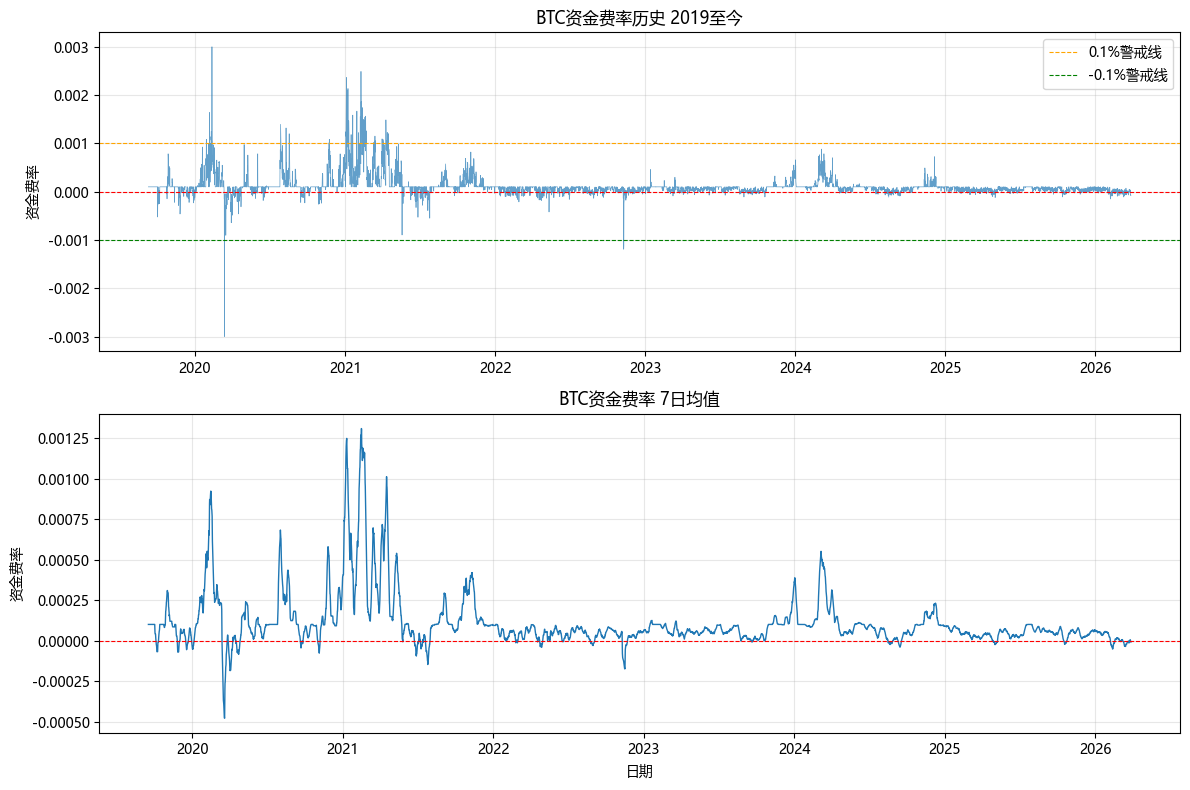

资金费率均值：0.000111
资金费率最大值：0.003000
资金费率最小值：-0.003000
资金费率>0的比例：86.33%


In [37]:
# 画资金费率走势
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 上图：资金费率原始数据
ax1.plot(df_funding.index, df_funding["rate"], linewidth=0.5, alpha=0.7)
ax1.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax1.axhline(y=0.001, color="orange", linewidth=0.8, linestyle="--", label="0.1%警戒线")
ax1.axhline(y=-0.001, color="green", linewidth=0.8, linestyle="--", label="-0.1%警戒线")
ax1.set_title("BTC资金费率历史 2019至今")
ax1.set_ylabel("资金费率")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 下图：7日移动平均，更平滑
df_funding["rate_ma7"] = df_funding["rate"].rolling(21).mean()  # 每天3次，21=7天
ax2.plot(df_funding.index, df_funding["rate_ma7"], linewidth=1)
ax2.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax2.set_title("BTC资金费率 7日均值")
ax2.set_ylabel("资金费率")
ax2.set_xlabel("日期")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"资金费率均值：{df_funding['rate'].mean():.6f}")
print(f"资金费率最大值：{df_funding['rate'].max():.6f}")
print(f"资金费率最小值：{df_funding['rate'].min():.6f}")
print(f"资金费率>0的比例：{(df_funding['rate']>0).mean():.2%}")

In [38]:
# 把资金费率转成日频数据（每天3次取均值）
df_funding_daily = df_funding["rate"].resample("D").mean()

# 7日移动平均
funding_ma7 = df_funding_daily.rolling(7).mean()

# 和BTC收盘价对齐
close_btc = df_btc["close"]
common_dates = close_btc.index.intersection(funding_ma7.index)

close_btc = close_btc[common_dates]
funding_signal = funding_ma7[common_dates]

# 生成信号：资金费率过高时空仓
signal_funding = pd.Series(1, index=common_dates)
signal_funding[funding_signal > 0.0001] = 0  # 超过0.01%空仓

print(f"持仓天数比例：{signal_funding.mean():.2%}")
print(f"数据范围：{common_dates[0].date()} 到 {common_dates[-1].date()}")

持仓天数比例：85.38%
数据范围：2023-01-01 到 2026-03-28


资金费率策略 累计收益：120.82%
资金费率策略 年化收益：27.71%
资金费率策略 最大回撤：-49.54%
资金费率策略 Sharpe：0.7874
BTC买入持有 累计收益：301.59%


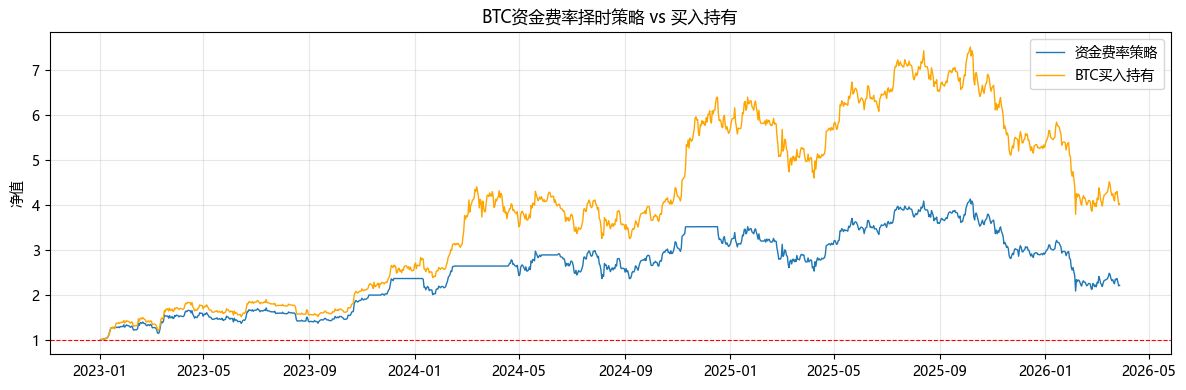

In [39]:
# 资金费率择时回测
ret = close_btc.pct_change().dropna()
sig = signal_funding.shift(1).dropna()
common = ret.index.intersection(sig.index)
strat_ret = ret[common] * sig[common]

portfolio_funding = (1 + strat_ret).cumprod()
buy_hold = (1 + ret[common]).cumprod()

# 指标
total_ret = portfolio_funding.iloc[-1] - 1
annual_ret = (1 + total_ret) ** (365/len(portfolio_funding)) - 1
max_dd = ((portfolio_funding - portfolio_funding.cummax()) / portfolio_funding.cummax()).min()
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
bh_ret = buy_hold.iloc[-1] - 1

print(f"资金费率策略 累计收益：{total_ret:.2%}")
print(f"资金费率策略 年化收益：{annual_ret:.2%}")
print(f"资金费率策略 最大回撤：{max_dd:.2%}")
print(f"资金费率策略 Sharpe：{sharpe:.4f}")
print(f"BTC买入持有 累计收益：{bh_ret:.2%}")

# 画图
plt.figure(figsize=(12, 4))
plt.plot(portfolio_funding.index, portfolio_funding, linewidth=1, label="资金费率策略")
plt.plot(buy_hold.index, buy_hold, linewidth=1, label="BTC买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC资金费率择时策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# 测试不同资金费率阈值
for threshold in [0.0001, 0.0003, 0.0005, 0.001, 0.002]:
    signal = pd.Series(1, index=common_dates)
    signal[funding_signal > threshold] = 0
    
    ret = close_btc.pct_change().dropna()
    sig = signal.shift(1).dropna()
    common = ret.index.intersection(sig.index)
    strat_ret = ret[common] * sig[common]
    
    pv = (1 + strat_ret).cumprod()
    sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
    total_ret = pv.iloc[-1] - 1
    dd = ((pv - pv.cummax()) / pv.cummax()).min()
    holding = signal.mean()
    
    print(f"阈值{threshold:.4f}：累计{total_ret:.2%}  Sharpe {sharpe:.4f}  回撤{dd:.2%}  持仓{holding:.2%}")

阈值0.0001：累计120.82%  Sharpe 0.7874  回撤-49.54%  持仓85.38%
阈值0.0003：累计310.79%  Sharpe 1.1707  回撤-49.54%  持仓97.89%
阈值0.0005：累计274.60%  Sharpe 1.0928  回撤-49.54%  持仓99.66%
阈值0.0010：累计301.59%  Sharpe 1.1372  回撤-49.54%  持仓100.00%
阈值0.0020：累计301.59%  Sharpe 1.1372  回撤-49.54%  持仓100.00%


组合策略 累计收益：319.25%
组合策略 Sharpe：1.6054
组合策略 最大回撤：-21.65%
持仓比例：46.83%


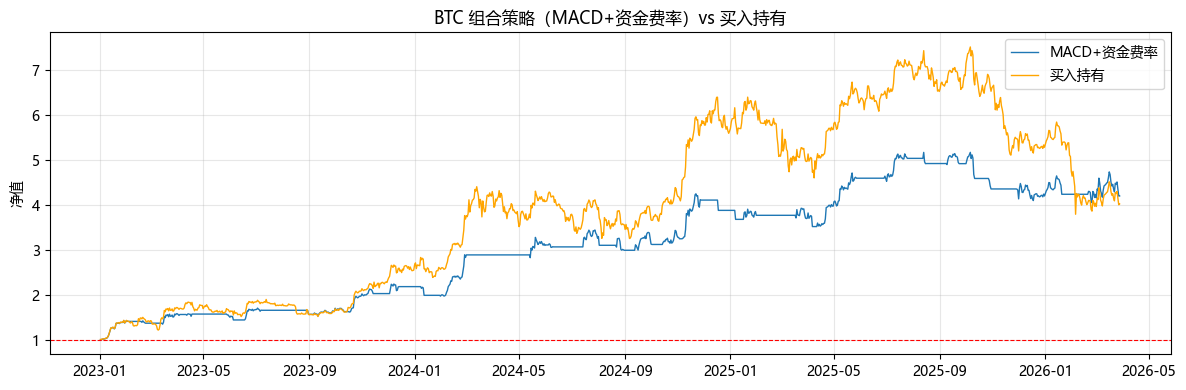

In [41]:
# 组合策略：MACD + 资金费率双重过滤
ema_fast = close_btc.ewm(span=16, adjust=False).mean()
ema_slow = close_btc.ewm(span=35, adjust=False).mean()
macd_line = ema_fast - ema_slow
signal_line = macd_line.ewm(span=9, adjust=False).mean()

macd_signal = pd.Series(0, index=close_btc.index)
macd_signal[macd_line > signal_line] = 1

funding_signal2 = pd.Series(1, index=common_dates)
funding_signal2[funding_signal > 0.0003] = 0

# 两个信号都满足才持仓
common = macd_signal.index.intersection(funding_signal2.index)
combined_signal = macd_signal[common] * funding_signal2[common]

ret = close_btc.pct_change().dropna()
sig = combined_signal.shift(1).dropna()
common2 = ret.index.intersection(sig.index)
strat_ret = ret[common2] * sig[common2]

pv = (1 + strat_ret).cumprod()
bh = (1 + ret[common2]).cumprod()

total_ret = pv.iloc[-1] - 1
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
dd = ((pv - pv.cummax()) / pv.cummax()).min()

print(f"组合策略 累计收益：{total_ret:.2%}")
print(f"组合策略 Sharpe：{sharpe:.4f}")
print(f"组合策略 最大回撤：{dd:.2%}")
print(f"持仓比例：{combined_signal.mean():.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv.index, pv, linewidth=1, label="MACD+资金费率")
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC 组合策略（MACD+资金费率）vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()